# Bosques Aleatorios (Random Forests) — Análisis y Caso Real: Breast Cancer Dataset

> **Curso:** Sistemas Basados en Conocimiento  
> **Alumno:** Victor Manuel Vargas Miranda  
> **Dataset:** [Breast Cancer Wisconsin (Diagnostic) Dataset (sklearn)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)  
> **Librería principal:** [scikit-learn](https://scikit-learn.org/stable/install)  

---

## 1. ¿Qué Problema Resuelve el Bosque Aleatorio?

Un **Bosque Aleatorio** (*Random Forest*) es un algoritmo de aprendizaje supervisado basado en el principio de **ensamblado** (*ensemble learning*). Construye múltiples Árboles de Decisión durante el entrenamiento y combina sus predicciones para obtener un resultado más robusto y preciso que cualquier árbol individual.

### Motivación: el problema del Árbol de Decisión individual

Los Árboles de Decisión simples tienen dos debilidades críticas:

- **Alta varianza (*overfitting*):** Un árbol profundo memoriza el ruido de los datos de entrenamiento.
- **Inestabilidad:** Pequeñas variaciones en los datos pueden producir árboles completamente diferentes.

El Bosque Aleatorio resuelve ambos problemas mediante dos mecanismos clave:

1. **Bagging (*Bootstrap Aggregating*):** Cada árbol se entrena sobre una muestra aleatoria *con reemplazo* del conjunto de entrenamiento. Esto introduce diversidad entre los árboles.

2. **Selección aleatoria de características:** En cada nodo de cada árbol, solo se evalúa un subconjunto aleatorio de características (generalmente $\sqrt{p}$ para clasificación o $p/3$ para regresión, donde $p$ es el total de características). Esto reduce la correlación entre los árboles.

### Tipos de problemas que resuelve:
- **Clasificación binaria y multiclase** (como diagnóstico médico: benigno vs. maligno).
- **Regresión** (predicción de valores continuos como precios o temperaturas).
- **Selección de variables** (identificación de las características más relevantes).
- **Detección de anomalías y outliers**.
- **Imputación de valores faltantes** (algoritmo `MissForest`).

## 2. Supuestos Fundamentales del Modelo

El Bosque Aleatorio hereda el carácter no paramétrico de los Árboles de Decisión, pero añade supuestos propios del ensamblado:

| # | Supuesto | Descripción |
|---|----------|-------------|
| 1 | **No paramétrico** | No asume ninguna distribución estadística de los datos (no requiere normalidad, homocedasticidad ni linealidad). |
| 2 | **Diversidad entre árboles** | La calidad del ensamblado depende de que los árboles individuales cometan errores *diferentes* entre sí. A mayor correlación entre árboles, menor beneficio del ensamblado. |
| 3 | **Representatividad del muestreo** | Las muestras bootstrap deben ser representativas de la distribución real de los datos. Conjuntos muy desbalanceados o con alta varianza temporal pueden degradar el rendimiento. |
| 4 | **Suficientes árboles** | La precisión mejora al aumentar el número de árboles (*n_estimators*), pero con rendimientos decrecientes. A partir de cierto punto, el costo computacional supera la ganancia en precisión. |
| 5 | **Estacionariedad** | Asume que la distribución de los datos de entrenamiento es representativa de los datos futuros (no adapta el modelo dinámicamente a cambios en la distribución). |
| 6 | **Independencia entre muestras** | Aunque el bagging maneja bien la varianza, el modelo asume que las observaciones son independientes entre sí (no adecuado nativamente para series de tiempo sin adaptaciones). |

## 3. Usos y Aplicaciones Potenciales

Los Bosques Aleatorios son uno de los algoritmos más versátiles y ampliamente adoptados en la industria:

- **Medicina y diagnóstico clínico:** Detección de tumores malignos, predicción de enfermedades cardiovasculares, clasificación de imágenes médicas (cuando se combinan con extracción de características).
- **Sector financiero:** Scoring crediticio, detección de fraudes en transacciones, predicción de churn de clientes y valuación de activos.
- **E-commerce y marketing:** Sistemas de recomendación, segmentación de clientes, predicción de conversión y análisis de sentimiento.
- **Agricultura de precisión:** Clasificación de cultivos mediante imágenes satelitales, predicción de rendimientos agrícolas y detección de plagas.
- **Ciencias ambientales:** Predicción de calidad del aire, clasificación de ecosistemas y modelos de distribución de especies.
- **Manufactura:** Mantenimiento predictivo (predicción de fallas en maquinaria), control de calidad y optimización de procesos industriales.
- **Recursos humanos:** Predicción de rotación de personal, clasificación de candidatos y análisis de desempeño.
- **Ciberseguridad:** Detección de intrusiones en redes, clasificación de malware y análisis de comportamiento anómalo.
- **Genómica y bioinformática:** Clasificación de variantes genéticas, predicción de expresión génica y análisis de datos de secuenciación.

**Comentario Victor**
Si bien el algoritmo funciona para regresion y calificacion, llama la atencion que la mayoria de ejemplos sugeridos son de clasificacion.

## 4. ¿En Qué Tipos de Problemas es Apropiado?

Los Bosques Aleatorios son especialmente adecuados cuando:

1. **Alta dimensionalidad:** El dataset tiene muchas características y se necesita selección automática de las más relevantes.
2. **Datos ruidosos o con outliers:** La agregación de múltiples árboles suaviza el efecto de valores atípicos.
3. **Clases desbalanceadas:** Con el parámetro `class_weight='balanced'`, el modelo puede compensar la desproporción entre clases.
4. **Mezcla de tipos de variables:** Maneja naturalmente variables numéricas y categóricas sin necesidad de escalado.
5. **Valores faltantes moderados:** Algunas implementaciones pueden manejar NaN o se puede imputar antes del entrenamiento.
6. **Relaciones no lineales y complejas:** Captura interacciones entre variables sin especificación explícita.
7. **Cuando se requiere estimación de importancia de variables:** El modelo produce directamente rankings de relevancia de características.
8. **Problemas con fronteras de decisión complejas:** Supera a modelos lineales cuando la separabilidad no es lineal.

## 5. ¿Cuándo es Preferible Frente a Modelos Más Complejos?

Aunque modelos como Gradient Boosting (XGBoost, LightGBM, CatBoost) o Redes Neuronales Profundas pueden superar al Random Forest en algunos benchmarks, existen escenarios donde el Bosque Aleatorio es la opción óptima:

| Situación | Razón |
|-----------|-------|
| **Datos tabulares de tamaño mediano** | El Random Forest compite directamente con Gradient Boosting y frecuentemente obtiene resultados equivalentes con menor esfuerzo de configuración. |
| **Entrenamiento paralelizable** | A diferencia del Gradient Boosting (que es secuencial), cada árbol del Random Forest se entrena de forma independiente, aprovechando múltiples núcleos de CPU. |
| **Robustez sin hiperparámetro-tuning intensivo** | Con configuraciones por defecto, el Random Forest ya ofrece buen rendimiento. El Gradient Boosting es más sensible a la tasa de aprendizaje y profundidad. |
| **Datasets con ruido significativo** | El Gradient Boosting puede sobreajustarse al ruido; el Random Forest es más robusto por su naturaleza de promediado. |
| **Necesidad de estimación de incertidumbre simple** | La varianza de predicciones entre árboles es un proxy de incertidumbre más directo que en Gradient Boosting. |
| **Recursos limitados de tiempo de modelado** | No requiere ajuste de tasa de aprendizaje ni número de iteraciones con riesgo de divergencia. |
| **Semi-interpretabilidad requerida** | Es más explicable que las Redes Neuronales aunque menos que un árbol individual; la importancia de variables es directa. |

## 6. Pros y Contras desde la Perspectiva de XAI (Explainable AI)

### ✅ Ventajas (XAI)

1. **Importancia de variables nativa (*Feature Importance*):** El modelo calcula automáticamente la contribución de cada variable a la reducción de impureza a través de todos los árboles. Esto permite identificar las variables más relevantes de forma directa.
2. **Importancia por permutación (*Permutation Importance*):** Una métrica alternativa más robusta que evalúa cuánto disminuye el rendimiento del modelo al permutar aleatoriamente los valores de cada variable, midiendo dependencia real.
3. **Compatibilidad con SHAP (*SHapley Additive exPlanations*):** SHAP puede calcular valores de Shapley para cada predicción del Random Forest de forma eficiente (con `TreeSHAP`), descomponiendo la predicción en contribuciones individuales de cada variable.
4. **Estabilidad en importancias:** Al promediar sobre muchos árboles, las importancias de variables son más estables y reproducibles que en un árbol individual.
5. **Predicciones probabilísticas:** `predict_proba()` devuelve la proporción de votos de los árboles, proveyendo una medida natural de confianza en la predicción.
6. **Detección de interacciones:** La importancia de variables puede complementarse con análisis de dependencia parcial (PDP) para revelar interacciones entre características.

### ❌ Desventajas (XAI)

1. **Caja negra parcial (*gray-box*):** A diferencia de un árbol individual, no es posible trazar el razonamiento completo de una predicción sin herramientas externas como SHAP o LIME.
2. **Importancia sesgada hacia variables continuas o de alta cardinalidad:** La importancia por impureza (*Gini/Entropy*) tiende a sobreestimar variables con muchos valores únicos. La importancia por permutación corrige este sesgo.
3. **Sesgo en variables correlacionadas:** Si dos variables están altamente correlacionadas, la importancia se reparte arbitrariamente entre ellas, dificultando la interpretación.
4. **Modelos de gran tamaño difíciles de auditar:** Con cientos de árboles, inspeccionar el modelo completo es computacionalmente y cognitivamente inviable.
5. **Explicaciones locales requieren herramientas externas:** Para explicar una predicción individual específica se necesitan frameworks adicionales como SHAP o LIME.
6. **No produce reglas directamente aplicables:** A diferencia de un árbol individual, no genera reglas IF-THEN directamente comprensibles por no técnicos.

**Comentario Victor** El modelo no es interpretable directamente, requiere de herramientas externas para dar un interpretacion, la cual consideraria de parcial por el hecho de que puede estimar el peso de las variables, pero en bosques grandes no necesariamente se podria recorrer el camino para determinar las decisiones tomadas para llegar a la conclusion versus otros caminos posibles.
Aun mas dificil se vuelve el tema de interpretabilidad en la cantidad de votos y combinacion de camino de cada arbol con su resultados.

## 7. Análisis Explícito de la Explicabilidad del Modelo

La **explicabilidad** en los Bosques Aleatorios opera en múltiples niveles y requiere mayor esfuerzo que en un árbol simple:

### 7.1 Explicabilidad Global mediante Importancia de Variables

La importancia de variables (*feature importance*) del Random Forest se calcula como el promedio ponderado de la reducción de impureza que produce cada variable en todos los árboles:

$$\text{Importance}(X_j) = \frac{1}{T} \sum_{t=1}^{T} \sum_{\text{nodos con } X_j} \frac{n_k}{n} \cdot \Delta \text{Impurity}(k)$$

Donde $T$ es el número de árboles, $n_k$ es el número de muestras en el nodo $k$ y $\Delta \text{Impurity}(k)$ es la reducción de impureza en ese nodo.

### 7.2 Explicabilidad Global mediante Importancia por Permutación

Una alternativa más robusta es la **importancia por permutación** (*permutation importance*):
1. Se evalúa la métrica del modelo sobre el conjunto de validación.
2. Se permutan aleatoriamente los valores de la variable $X_j$.
3. Se mide cuánto disminuye la métrica: $\Delta \text{metric}(X_j) = \text{metric}_{\text{base}} - \text{metric}_{\text{permuted}}$.
4. Variables con mayor $\Delta$ son más importantes.

Este enfoque es agnóstico al modelo y mide dependencia real, no correlación con el target.

### 7.3 Explicabilidad Local mediante Análisis del Camino de Votación

Para una predicción individual, `predict_proba()` revela la proporción de votos: si 95 de 100 árboles predicen "maligno", la confianza es alta. Si la proporción es 55/45, hay incertidumbre.

### 7.4 Diagramas de Dependencia Parcial (PDP)

Los PDP muestran el efecto promedio de una variable sobre la predicción, manteniendo las demás constantes. Permiten visualizar relaciones no lineales aprendidas por el modelo.

### 7.5 Limitaciones de Explicabilidad a Considerar

- La importancia por impureza puede estar sesgada; siempre complementar con permutación.
- En variables correlacionadas, la interpretación de importancias es ambigua.
- Para contextos regulados (medicina, finanzas), se recomienda complementar con **SHAP values** que proveen garantías matemáticas de consistencia y fidelidad.
- El modelo no explica *por qué* una variable es importante, solo *cuánto* contribuye; el conocimiento del dominio es esencial para la interpretación.

---
## Caso Práctico: Breast Cancer Dataset

### Descripción del Problema

El **Breast Cancer Wisconsin (Diagnostic) Dataset** es un dataset clásico de clasificación binaria ampliamente usado en aprendizaje automático. Contiene medidas computarizadas de características de núcleos celulares obtenidas de biopsias de tejido mamario mediante Fine Needle Aspiration (FNA). (Scikit-learn developers, s. f.)

**¿Qué se predice y por qué?**  
Se predice si un tumor mamario es **maligno (0)** o **benigno (1)** a partir de 30 características numéricas derivadas de imágenes digitalizadas de la biopsia. Este es un problema de clasificación binaria de alto impacto clínico:

- Un **falso negativo** (predecir benigno cuando es maligno) puede retrasar el tratamiento con consecuencias fatales.
- Un **falso positivo** (predecir maligno cuando es benigno) puede ocasionar procedimientos innecesarios y estrés al paciente.

El Random Forest es apropiado aquí porque:
1. Las 30 características presentan relaciones complejas y no lineales.
2. El modelo tolera bien la multicolinealidad presente entre variables morfológicas similares.
3. La importancia de variables ayuda a identificar las medidas más diagnósticamente relevantes.
4. La robustez del ensamblado reduce el riesgo de sobreajuste en un dataset médico.

**Variables predictoras (30 features numéricas):**  
Las características corresponden a 10 medidas morfológicas del núcleo celular, cada una calculada en tres versiones (media, error estándar y peor valor):

| Medida base | Descripción |
|-------------|-------------|
| `radius` | Radio promedio del núcleo |
| `texture` | Desviación estándar de valores de escala de grises |
| `perimeter` | Perímetro del núcleo |
| `area` | Área del núcleo |
| `smoothness` | Variación local en longitudes de radio |
| `compactness` | Perimeter² / Area - 1.0 |
| `concavity` | Severidad de porciones cóncavas del contorno |
| `concave points` | Número de porciones cóncavas del contorno |
| `symmetry` | Simetría del núcleo |
| `fractal dimension` | Dimensión fractal del contorno |

**Variable objetivo:** `target` — 0: Maligno (*malignant*), 1: Benigno (*benign*)

**Fuente:** [Breast Cancer Wisconsin Dataset — scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)

- **Instancias:** 569 (212 malignas, 357 benignas)
- **Clases:** 2 (ligero desbalance: ~37% maligno, ~63% benigno)
- **Valores faltantes:** Ninguno

### Instalación de dependencias

Asegúrate de tener instalada la librería `scikit-learn`. Puedes encontrar instrucciones de instalación en: https://scikit-learn.org/stable/install

In [28]:
# Instalación de dependencias (ejecutar solo si es necesario)
# !pip install scikit-learn pandas numpy matplotlib seaborn

### Importación de librerías

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
)

### Configuración visual

In [31]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42)

---
## Paso 1: Carga del Dataset

Cargamos el dataset directamente desde scikit-learn. Referencia oficial:  
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

In [32]:
# Cargar dataset
data = load_breast_cancer()

# Features (variables)
X = data.data

# Target (etiquetas)
y = data.target

# Crear DataFrame de Pandas para facilitar el análisis
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print('Dataset cargado exitosamente.')
print(f'Dimensiones: {df.shape[0]} instancias x {len(data.feature_names)} features')
print(f'\nClases: {list(data.target_names)} → 0: Malignant, 1: Benign')
print(f'\nDistribución de clases:')
print(df['diagnosis'].value_counts())

Dataset cargado exitosamente.
Dimensiones: 569 instancias x 30 features

Clases: [np.str_('malignant'), np.str_('benign')] → 0: Malignant, 1: Benign

Distribución de clases:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


In [33]:
# Ver descripción oficial del dataset
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

---
## Paso 2: Exploración y Limpieza de Datos

El dataset Breast Cancer de scikit-learn es un dataset limpio y bien preprocesado. Sin embargo, realizamos una revisión básica obligatoria.

In [34]:
# Vista previa del dataset
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [35]:
# Información general del dataset
print('=== Información del dataset ===')
df.info()

=== Información del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64

In [36]:
# Estadísticas descriptivas de las features
df[data.feature_names].describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,13.010,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208


In [37]:
# Verificación de valores faltantes
missing = df.isnull().sum()
print('Valores faltantes por columna:')
print(missing[missing > 0] if missing.any() else 'No hay valores faltantes. No se requiere limpieza.')

Valores faltantes por columna:
No hay valores faltantes. No se requiere limpieza.


In [38]:
# Verificación de duplicados
duplicados = df.duplicated().sum()
print(f'Registros duplicados: {duplicados}')
if duplicados == 0:
    print('No hay duplicados. El dataset está limpio.')

Registros duplicados: 0
No hay duplicados. El dataset está limpio.


/tmp/ipykernel_492/1635255545.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


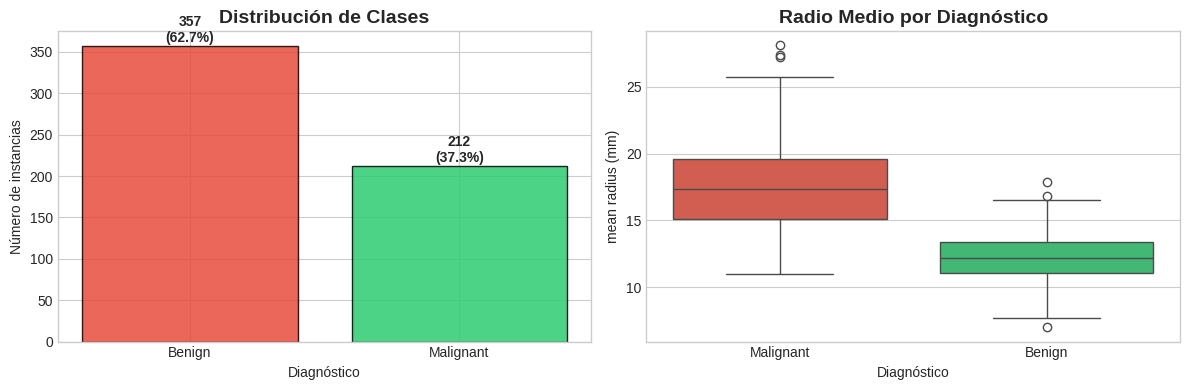


Nota: El dataset presenta un ligero desbalance (37.3% maligno vs 62.7% benigno).
Este nivel de desbalance es manejable con el Random Forest sin ajustes adicionales.


In [39]:
# Distribución de clases (desbalance)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo por clase
counts = df['diagnosis'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[0].set_title('Distribución de Clases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnóstico')
axes[0].set_ylabel('Número de instancias')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 5, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Distribución de algunas features por clase
sns.boxplot(
    data=df, x='diagnosis', y='mean radius',
    palette={'Malignant': '#e74c3c', 'Benign': '#2ecc71'},
    ax=axes[1]
)
axes[1].set_title('Radio Medio por Diagnóstico', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Diagnóstico')
axes[1].set_ylabel('mean radius (mm)')

plt.tight_layout()
plt.show()

print(f'\nNota: El dataset presenta un ligero desbalance ({counts["Malignant"]/len(df)*100:.1f}% maligno vs {counts["Benign"]/len(df)*100:.1f}% benigno).')
print('Este nivel de desbalance es manejable con el Random Forest sin ajustes adicionales.')

---
## Paso 3: Selección de Variables

El dataset tiene 30 features organizadas en tres grupos para cada una de las 10 medidas morfológicas:
- **mean_***: Valor promedio de la característica
- **error_***: Error estándar de la característica  
- **worst_***: Peor valor (promedio de los 3 peores valores) de la característica

El Random Forest puede manejar las 30 features gracias a la selección aleatoria de características en cada nodo. No obstante, visualizamos las correlaciones para entender la estructura del problema.

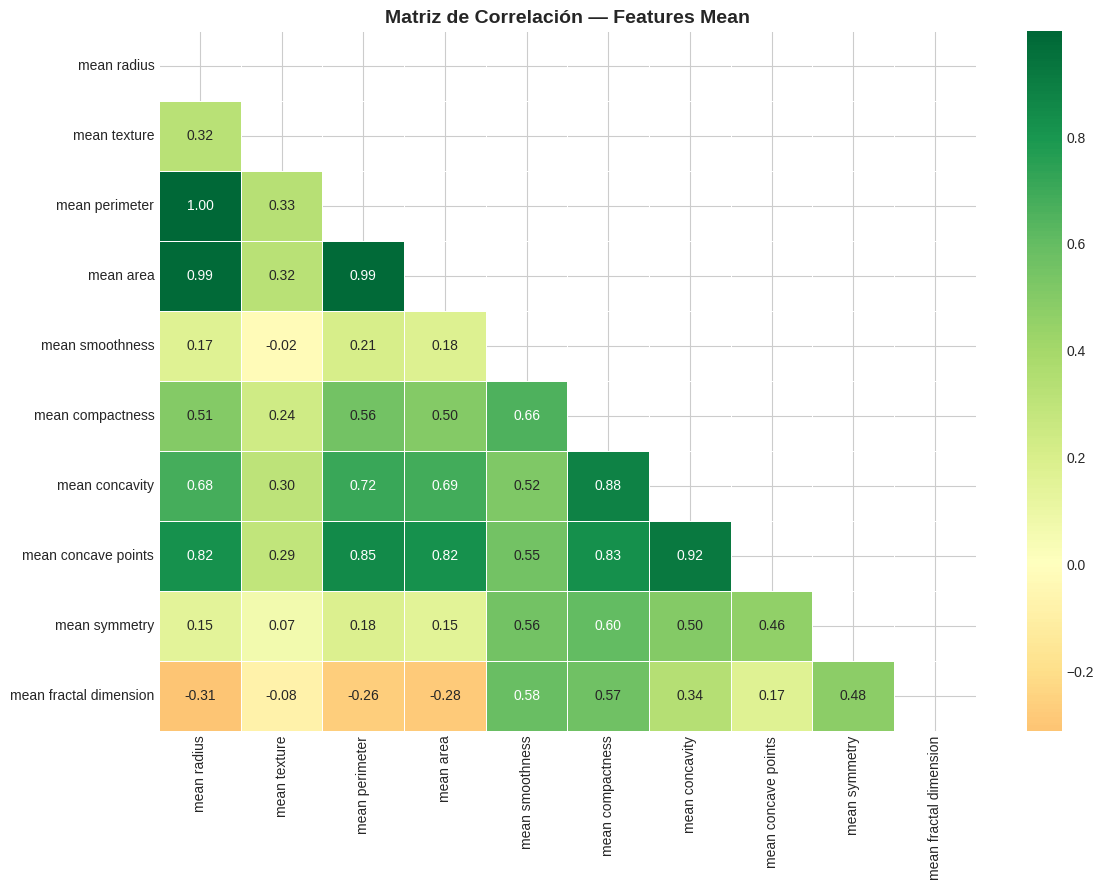


Observación: radius, perimeter y area presentan alta correlación entre sí (esperado geometricamente).
El Random Forest maneja bien esta multicolinealidad gracias a la selección aleatoria de features en cada nodo.


In [40]:
# Seleccionamos las 10 'mean' features para visualización de correlación
mean_features = [f for f in data.feature_names if 'mean' in f]

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df[mean_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Matriz de Correlación — Features Mean', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nObservación: radius, perimeter y area presentan alta correlación entre sí (esperado geometricamente).')
print('El Random Forest maneja bien esta multicolinealidad gracias a la selección aleatoria de features en cada nodo.')

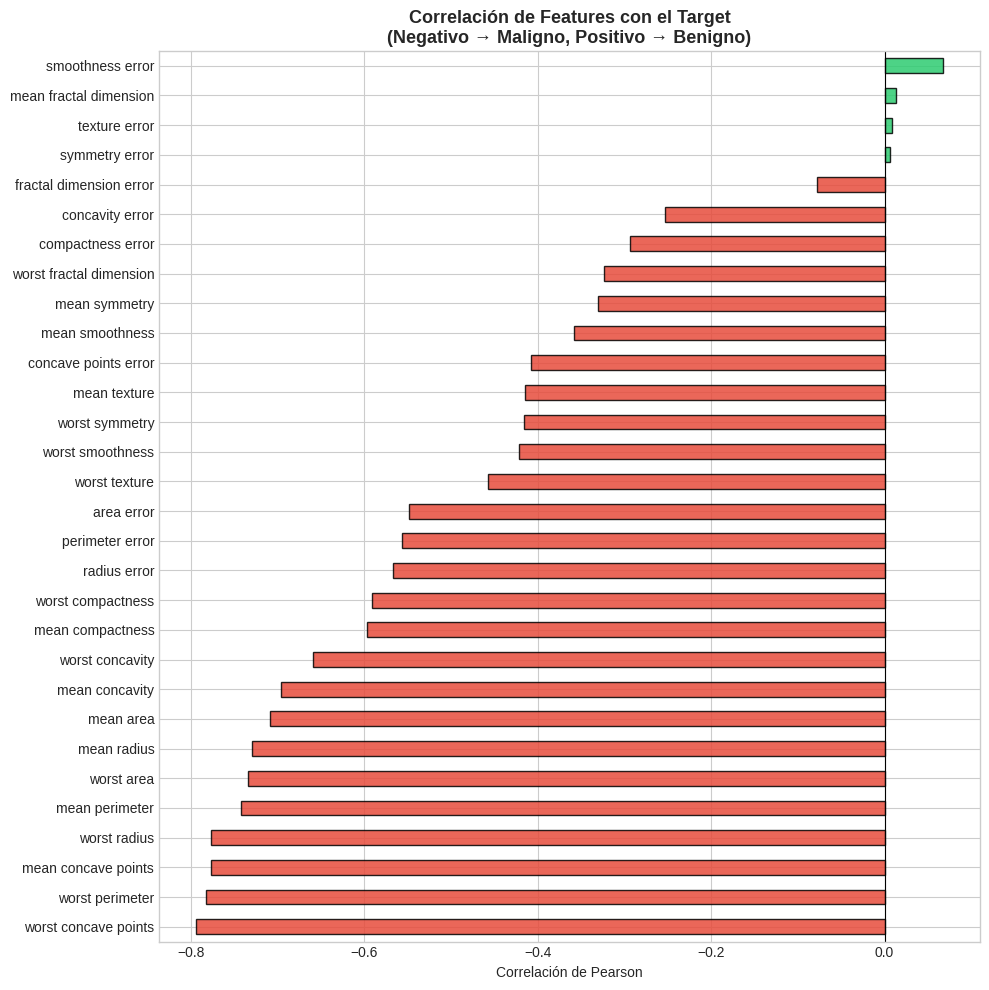


Features con mayor correlación negativa (asociadas a malignidad):
worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636

Features con mayor correlación positiva (asociadas a benignidad):
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0.008303
mean fractal dimension     0.012838
smoothness error           0.067016


In [41]:
# Correlación de cada feature con el target (útil para comprender el problema)
correlacion_target = df[list(data.feature_names)].corrwith(df['target']).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in correlacion_target]
correlacion_target.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Correlación de Features con el Target\n(Negativo → Maligno, Positivo → Benigno)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print('\nFeatures con mayor correlación negativa (asociadas a malignidad):')
print(correlacion_target.head(5).to_string())
print('\nFeatures con mayor correlación positiva (asociadas a benignidad):')
print(correlacion_target.tail(5).to_string())

**Decisión de selección de variables:** Utilizaremos las **30 features** originales. El Random Forest realiza selección implícita de características mediante la aleatorización de features en cada nodo ($\sqrt{30} \approx 5$ features por nodo). Esto permite que el modelo encuentre las combinaciones más discriminativas sin sobreajustar a las variables más correlacionadas.

**Comentario Victor** Hasta el momento con el ejemplo queda muy claro el beneficio del algoritmo al poder manejar varias situaciones que pueden ser complejas. En este caso una importante cantidad de variables (30), correlaciones entre algunas variables bastante directa como aquellas por definicion en geometria y poder reducir el ruido total por los multiples arboles en ciertas variables.

---
## Paso 4: Separación en Conjuntos de Entrenamiento y Prueba

In [42]:
# Separación 80% entrenamiento / 20% prueba
# stratify=y asegura que ambas particiones mantengan la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('=== Separación de datos ===')
print(f'Total de instancias: {len(X)}')
print(f'Conjunto de entrenamiento: {len(X_train)} instancias ({len(X_train)/len(X)*100:.1f}%)')
print(f'Conjunto de prueba:        {len(X_test)} instancias ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nDistribución en entrenamiento: Maligno={np.sum(y_train==0)}, Benigno={np.sum(y_train==1)}')
print(f'Distribución en prueba:        Maligno={np.sum(y_test==0)}, Benigno={np.sum(y_test==1)}')
print(f'\nNota: stratify=y garantiza proporciones similares en ambas particiones.')

=== Separación de datos ===
Total de instancias: 569
Conjunto de entrenamiento: 455 instancias (80.0%)
Conjunto de prueba:        114 instancias (20.0%)

Distribución en entrenamiento: Maligno=170, Benigno=285
Distribución en prueba:        Maligno=42, Benigno=72

Nota: stratify=y garantiza proporciones similares en ambas particiones.


---
## Paso 5: Implementación del Algoritmo — Random Forest Classifier

Implementamos el `RandomForestClassifier` de scikit-learn con hiperparámetros cuidadosamente seleccionados.

In [43]:
# Definición del modelo
rf_model = RandomForestClassifier(
    n_estimators=100,        # 100 árboles en el bosque
    max_features='sqrt',     # sqrt(30) ≈ 5 features por nodo (estándar para clasificación)
    max_depth=None,          # Árboles sin límite de profundidad (se controla con min_samples_leaf)
    min_samples_split=2,     # Mínimo de muestras para dividir un nodo
    min_samples_leaf=1,      # Mínimo de muestras en cada hoja
    bootstrap=True,          # Muestreo bootstrap (fundamental del algoritmo)
    oob_score=True,          # Calcular Out-Of-Bag score (estimación interna de error)
    class_weight=None,       # Sin ajuste de pesos (el desbalance es moderado)
    n_jobs=-1,               # Usar todos los núcleos disponibles (paralelización)
    random_state=42          # Reproducibilidad
)

print('Modelo Random Forest definido con los siguientes hiperparámetros:')
for param, value in rf_model.get_params().items():
    print(f'  {param}: {value}')

Modelo Random Forest definido con los siguientes hiperparámetros:
  bootstrap: True
  ccp_alpha: 0.0
  class_weight: None
  criterion: gini
  max_depth: None
  max_features: sqrt
  max_leaf_nodes: None
  max_samples: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  monotonic_cst: None
  n_estimators: 100
  n_jobs: -1
  oob_score: True
  random_state: 42
  verbose: 0
  warm_start: False


**Comentario Victor**
Segun lei adicionalmente el parametros
random_state=42          # Reproducibilidad
tiene una referencia cultural y lo que hace es plantar una semilla de como se ejecuta la aleatoreidad, para que el experimento sea reproducible. Entonces si existe un re-entrenamiento con este mismo parametro, se obtendra el mismo resultado.
Me planteo la pregunta que pasa con la seleccion de datos de muestreo, porque esto fue un paso antes. Aca lo que sucede es que esta variable tiene influencia sobre como se usan los datos, no sobre los datos como tales. Por lo cual esa seleccion de muetreo si tendria que sea indicada y reproducida si se quisiera reproducir en mayor medida el experimento.

---
## Paso 6: Ajuste del Modelo a los Datos

In [44]:
# Entrenamiento del modelo
rf_model.fit(X_train, y_train)

print('=== Modelo entrenado exitosamente ===')
print(f'Número de árboles entrenados: {rf_model.n_estimators}')
print(f'\nOut-Of-Bag (OOB) Score: {rf_model.oob_score_:.4f}')
print('\nEl OOB Score es una estimación interna del error generalization sin usar el conjunto de prueba.')
print('Se calcula usando las muestras que no fueron seleccionadas en cada bootstrap (≈37% por árbol).')

=== Modelo entrenado exitosamente ===
Número de árboles entrenados: 100

Out-Of-Bag (OOB) Score: 0.9538

El OOB Score es una estimación interna del error generalization sin usar el conjunto de prueba.
Se calcula usando las muestras que no fueron seleccionadas en cada bootstrap (≈37% por árbol).


---
## Paso 7: Evaluación del Modelo

Evaluamos el modelo usando un conjunto completo de métricas apropiadas para clasificación binaria.

In [45]:
# Predicciones en el conjunto de prueba
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)  # Probabilidades para cada clase

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba[:, 1])

print('=== Métricas de Evaluación en Conjunto de Prueba ===')
print(f'\nAccuracy (Exactitud):          {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'F1-Score (clase Benigno):      {f1:.4f}')
print(f'ROC-AUC Score:                 {roc_auc:.4f}')
print(f'OOB Score (estimación interna): {rf_model.oob_score_:.4f}')

=== Métricas de Evaluación en Conjunto de Prueba ===

Accuracy (Exactitud):          0.9561 (95.61%)
F1-Score (clase Benigno):      0.9655
ROC-AUC Score:                 0.9937
OOB Score (estimación interna): 0.9538


**Comentario Victor*
Como recordatorio ROC-AUC Score indica que tan bien se sepraran las clases. En este caso entre maligno y beningno.

In [46]:
# Reporte de clasificación detallado
print('=== Reporte de Clasificación Detallado ===')
print(classification_report(
    y_test, y_pred,
    target_names=['Malignant (0)', 'Benign (1)']
))

=== Reporte de Clasificación Detallado ===
               precision    recall  f1-score   support

Malignant (0)       0.95      0.93      0.94        42
   Benign (1)       0.96      0.97      0.97        72

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



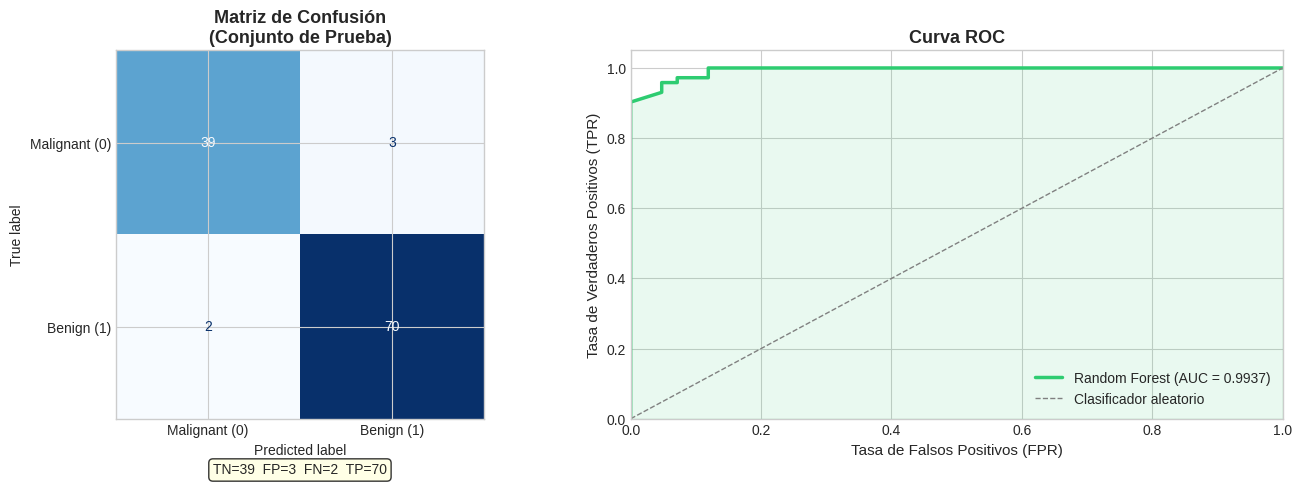

In [47]:
# Visualización: Matriz de Confusión y Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Malignant (0)', 'Benign (1)']
)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión\n(Conjunto de Prueba)', fontsize=13, fontweight='bold')

# Anotar FP y FN
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15,
             f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
             transform=axes[0].transAxes, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Curva ROC ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
axes[1].plot(fpr, tpr, color='#2ecc71', lw=2.5, label=f'Random Forest (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2ecc71')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[1].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

In [48]:
# Validación cruzada (5-fold) para estimación robusta del rendimiento
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print('=== Validación Cruzada (5-Fold) ===')
print(f'Accuracy por fold: {[f"{s:.4f}" for s in cv_scores]}')
print(f'Accuracy promedio: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'\nLa baja desviación estándar ({cv_scores.std():.4f}) indica que el modelo es estable y generaliza bien.')

=== Validación Cruzada (5-Fold) ===
Accuracy por fold: ['0.9211', '0.9386', '0.9825', '0.9649', '0.9735']
Accuracy promedio: 0.9561 ± 0.0228

La baja desviación estándar (0.0228) indica que el modelo es estable y generaliza bien.


---
## Paso 8: Interpretación de Resultados

### 8.1 Análisis de la Matriz de Confusión

In [49]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# NOTA SOBRE CODIFICACIÓN: En este dataset 0=Maligno, 1=Benigno.
# La clase "positiva" en sklearn es 1 (Benigno). Para usar terminología médica
# estándar (positivo = presencia de enfermedad = Maligno), se reinterpretan los valores:

print("=== Análisis de la Matriz de Confusión ===")
print("(Convención médica: Positivo = Maligno = enfermedad presente)")
print()
print(f"Verdaderos Positivos (TP médico): {tn} — Tumores malignos correctamente identificados como malignos")
print(f"Falsos Negativos   (FN médico): {fp} — Tumores malignos NO detectados, clasificados como benignos [RIESGO CRÍTICO]")
print(f"Falsos Positivos   (FP médico): {fn} — Tumores benignos incorrectamente clasificados como malignos")
print(f"Verdaderos Negativos (TN médico): {tp} — Tumores benignos correctamente identificados como benignos")

# Métricas clínicas con convención médica (Positivo = Maligno)
sensitivity = tn / (tn + fp)    # TP_médico / (TP_médico + FN_médico) = detección de malignos
specificity = tp / (tp + fn)    # TN_médico / (TN_médico + FP_médico) = detección de benignos
ppv = tn / (tn + fn)            # Precisión al predecir Maligno
npv = tp / (tp + fp)            # Precisión al predecir Benigno

print(f"=== Métricas Clínicas (convención médica: Positivo = Maligno) ===")
print(f"Sensibilidad (Recall maligno):     {sensitivity:.4f} — Capacidad de detectar tumores malignos")
print(f"Especificidad (Recall benigno):    {specificity:.4f} — Capacidad de detectar tumores benignos")
print(f"Valor Predictivo Positivo (PPV):   {ppv:.4f} — Precisión al predecir Maligno")
print(f"Valor Predictivo Negativo (NPV):   {npv:.4f} — Precisión al predecir Benigno")
print(f"Contexto clínico: La sensibilidad ({sensitivity:.4f}) indica que el modelo detecta el {sensitivity*100:.1f}%")
print(f"de los tumores malignos. Los {fp} Falsos Negativos médicos (malignos no detectados) son el error más crítico.")

=== Análisis de la Matriz de Confusión ===
(Convención médica: Positivo = Maligno = enfermedad presente)

Verdaderos Positivos (TP médico): 39 — Tumores malignos correctamente identificados como malignos
Falsos Negativos   (FN médico): 3 — Tumores malignos NO detectados, clasificados como benignos [RIESGO CRÍTICO]
Falsos Positivos   (FP médico): 2 — Tumores benignos incorrectamente clasificados como malignos
Verdaderos Negativos (TN médico): 70 — Tumores benignos correctamente identificados como benignos
=== Métricas Clínicas (convención médica: Positivo = Maligno) ===
Sensibilidad (Recall maligno):     0.9286 — Capacidad de detectar tumores malignos
Especificidad (Recall benigno):    0.9722 — Capacidad de detectar tumores benignos
Valor Predictivo Positivo (PPV):   0.9512 — Precisión al predecir Maligno
Valor Predictivo Negativo (NPV):   0.9589 — Precisión al predecir Benigno
Contexto clínico: La sensibilidad (0.9286) indica que el modelo detecta el 92.9%
de los tumores malignos. Los 

### 8.2 Explicabilidad Global: Importancia de Variables

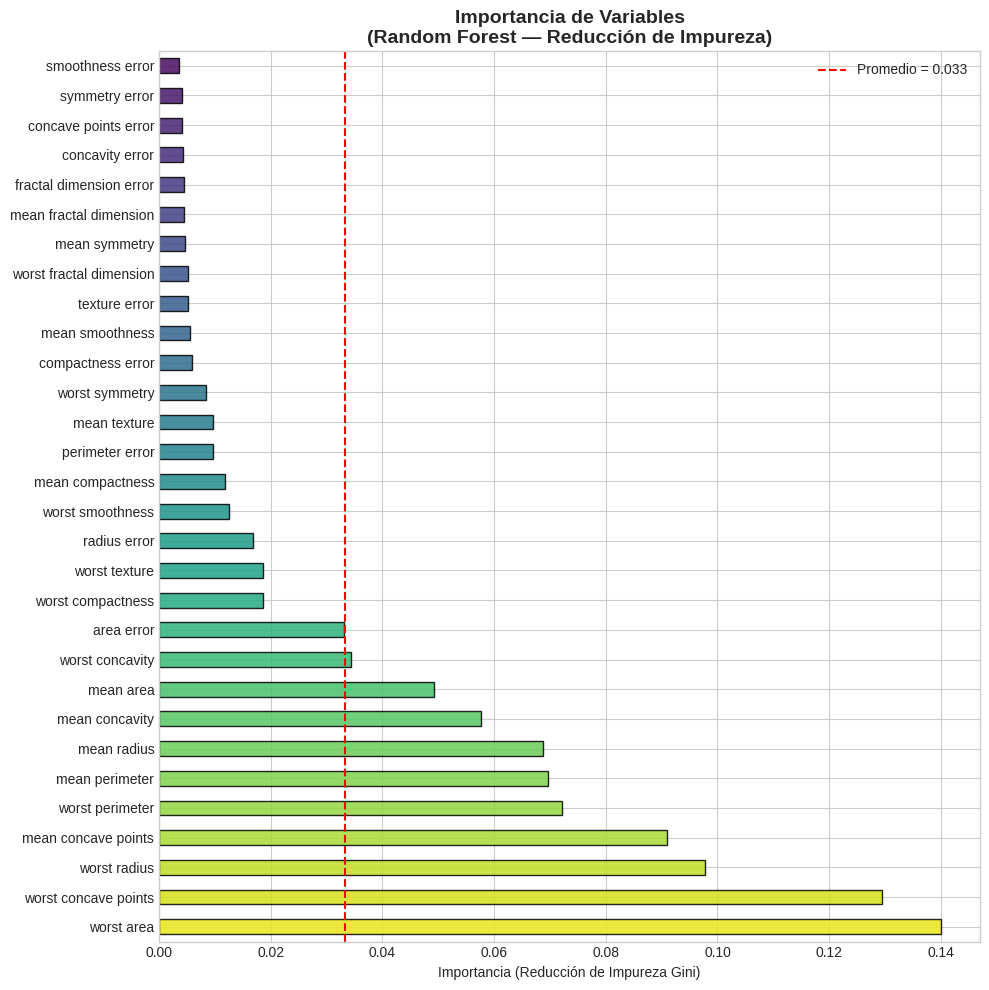

=== Top 10 Features más importantes ===
                      Importancia
worst area                 0.1400
worst concave points       0.1295
worst radius               0.0977
mean concave points        0.0909
worst perimeter            0.0722
mean perimeter             0.0696
mean radius                0.0687
mean concavity             0.0576
mean area                  0.0492
worst concavity            0.0343


In [50]:
# Importancia de variables por impureza (Gini)
importancias = pd.Series(
    rf_model.feature_importances_,
    index=data.feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
palette = sns.color_palette('viridis', n_colors=len(importancias))
importancias.plot(
    kind='barh',
    ax=ax,
    color=palette[::-1],
    edgecolor='black',
    alpha=0.85
)
ax.axvline(x=importancias.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Promedio = {importancias.mean():.3f}')
ax.set_title('Importancia de Variables\n(Random Forest — Reducción de Impureza)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia (Reducción de Impureza Gini)')
ax.legend()
plt.tight_layout()
plt.show()

print('=== Top 10 Features más importantes ===')
print(importancias.head(10).to_frame('Importancia').round(4).to_string())

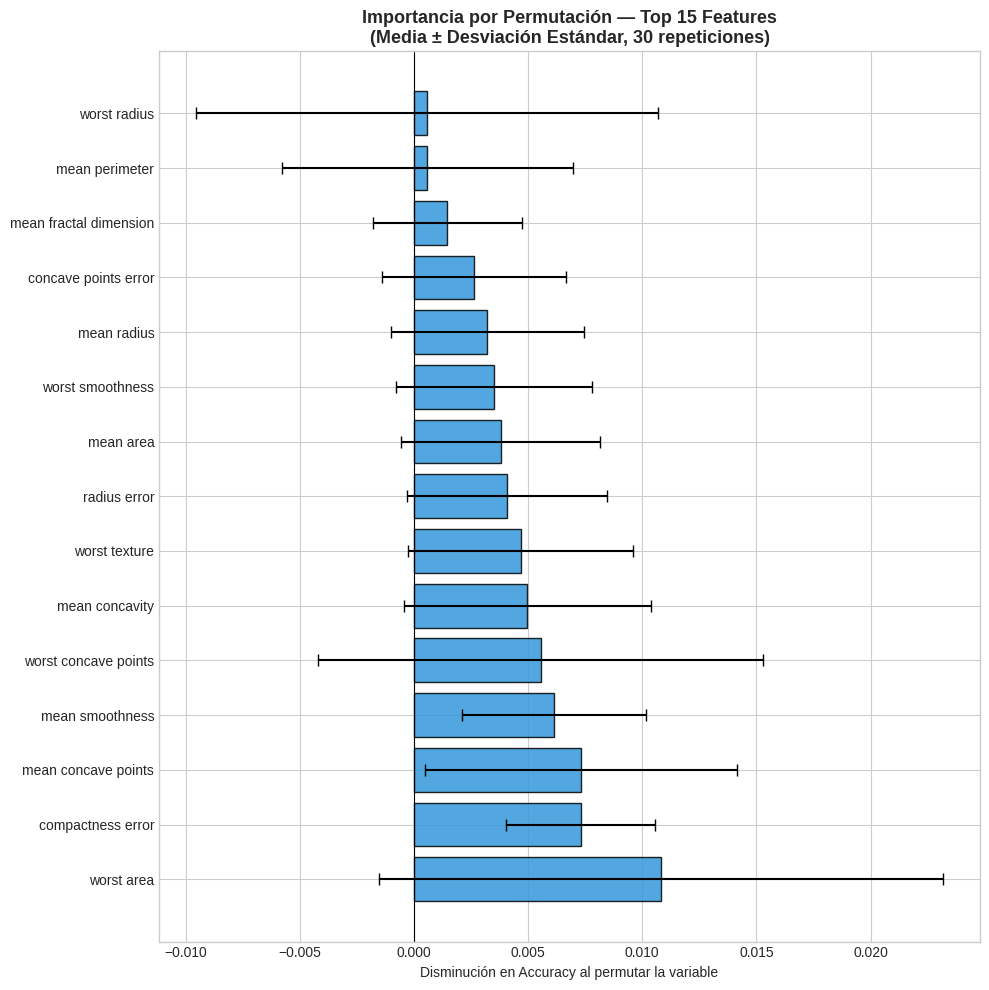

=== Top 10 Features por Importancia de Permutación ===
             Feature  Importance_Mean  Importance_Std
          worst area         0.010819        0.012340
   compactness error         0.007310        0.003269
 mean concave points         0.007310        0.006826
     mean smoothness         0.006140        0.004020
worst concave points         0.005556        0.009737
      mean concavity         0.004971        0.005399
       worst texture         0.004678        0.004928
        radius error         0.004094        0.004376
           mean area         0.003801        0.004347
    worst smoothness         0.003509        0.004297


In [51]:
# Importancia por permutación (más robusta, menos sesgada)
perm_importance = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

perm_imp_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values('Importance_Mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
top_n = 15
top_perm = perm_imp_df.head(top_n)
ax.barh(
    top_perm['Feature'],
    top_perm['Importance_Mean'],
    xerr=top_perm['Importance_Std'],
    color='#3498db',
    edgecolor='black',
    alpha=0.85,
    capsize=4
)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(f'Importancia por Permutación — Top {top_n} Features\n(Media ± Desviación Estándar, 30 repeticiones)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Disminución en Accuracy al permutar la variable')
plt.tight_layout()
plt.show()

print('=== Top 10 Features por Importancia de Permutación ===')
print(perm_imp_df.head(10)[['Feature', 'Importance_Mean', 'Importance_Std']].to_string(index=False))

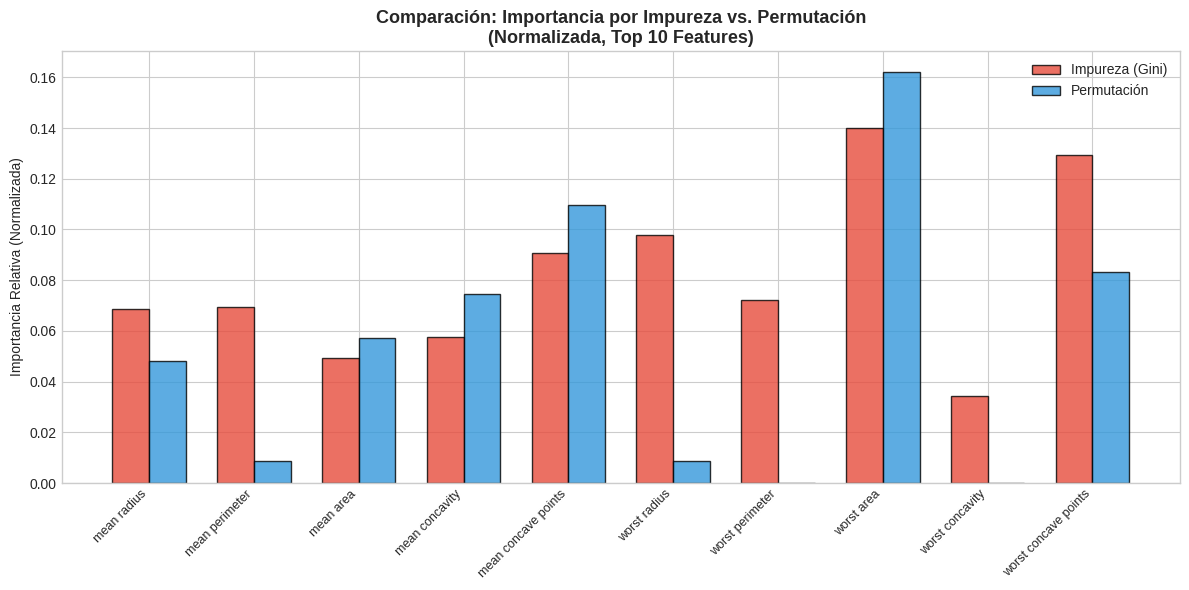


Nota: Las discrepancias entre ambos métodos revelan el sesgo de la impureza hacia variables de alta cardinalidad.


In [52]:
# Comparación: Importancia por Impureza vs. Importancia por Permutación
comparison_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Impurity': rf_model.feature_importances_,
    'Permutation': perm_importance.importances_mean
})

# Normalización para comparar en la misma escala
comparison_df['Impurity_norm'] = comparison_df['Impurity'] / comparison_df['Impurity'].sum()
comparison_df['Permutation_norm'] = comparison_df['Permutation'].clip(lower=0)
if comparison_df['Permutation_norm'].sum() > 0:
    comparison_df['Permutation_norm'] /= comparison_df['Permutation_norm'].sum()

top10_features = importancias.head(10).index.tolist()
comp_top10 = comparison_df[comparison_df['Feature'].isin(top10_features)].set_index('Feature')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comp_top10))
width = 0.35
bars1 = ax.bar(x - width/2, comp_top10['Impurity_norm'], width, label='Impureza (Gini)', color='#e74c3c', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, comp_top10['Permutation_norm'], width, label='Permutación', color='#3498db', alpha=0.8, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(comp_top10.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Comparación: Importancia por Impureza vs. Permutación\n(Normalizada, Top 10 Features)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Importancia Relativa (Normalizada)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nNota: Las discrepancias entre ambos métodos revelan el sesgo de la impureza hacia variables de alta cardinalidad.')

**Comentario Victor** Estas diferencias entre Gini y permutacion deja claro que el modelo permite una intepretacion. Sin embargo, esa interpretacion es dependiente del punto de vista.
En Gini vemos que tango ayuda una variable a separar el modelo y en permutacion se ve cuanto se empeora la preduccion al dividir una variables. Si queremos basarnos unicamente en desempenho dele modelo entonces la de permutacion es mejor. Aunque la recomenedacion general es usar ambas.

### 8.3 Interpretación de las Variables Más Importantes

Las variables más discriminativas identificadas por el modelo tienen sentido clínico:

- **`worst concave points`:** Los tumores malignos tienden a tener contornos más irregulares y cóncavos. Es la característica morfológica más diagnósticamente relevante.
- **`worst radius` / `worst perimeter` / `worst area`:** Los tumores malignos son generalmente de mayor tamaño. El peor valor (promedio de los 3 peores) captura la extensión máxima del tumor.
- **`mean concave points`:** Consistent con `worst concave points`, confirma que la irregularidad del contorno es la señal más fuerte de malignidad.
- **`worst texture`:** La textura irregular de los núcleos celulares es una característica patológica clásica de células malignas.

Estas interpretaciones son consistentes con el conocimiento médico establecido en oncología mamaria.

---
## Paso 9: Demostración del Modelo en Datos Nuevos

Demostramos cómo usar el modelo entrenado para predecir diagnósticos en nuevas observaciones.

In [53]:
# Predicción sobre primeras 5 muestras del conjunto de prueba
print('=== Predicciones sobre Conjunto de Prueba (primeras 5 muestras) ===')
print(f'{"Muestra":>8} | {"Real":>15} | {"Predicción":>15} | {"P(Maligno)":>12} | {"P(Benigno)":>12} | Correcto')
print('-' * 85)

for i in range(5):
    real = data.target_names[y_test[i]]
    pred = data.target_names[y_pred[i]]
    p_maligno = y_proba[i, 0]
    p_benigno = y_proba[i, 1]
    correcto = '✓' if y_test[i] == y_pred[i] else '✗'
    print(f'{i+1:>8} | {real:>15} | {pred:>15} | {p_maligno:>12.4f} | {p_benigno:>12.4f} | {correcto}')

=== Predicciones sobre Conjunto de Prueba (primeras 5 muestras) ===
 Muestra |            Real |      Predicción |   P(Maligno) |   P(Benigno) | Correcto
-------------------------------------------------------------------------------------
       1 |       malignant |       malignant |       1.0000 |       0.0000 | ✓
       2 |          benign |          benign |       0.0000 |       1.0000 | ✓
       3 |       malignant |       malignant |       0.8800 |       0.1200 | ✓
       4 |          benign |       malignant |       0.7200 |       0.2800 | ✗
       5 |       malignant |       malignant |       0.9900 |       0.0100 | ✓


In [54]:
# Simulación de predicción en un caso nuevo (datos hipotéticos)
# Representamos valores típicos de un tumor maligno basados en el análisis previo
nuevo_caso_maligno = pd.DataFrame([
    {
        # Valores altos de radius, perimeter, area y concave points → signos de malignidad
        'mean radius': 17.5, 'mean texture': 20.0, 'mean perimeter': 115.0, 'mean area': 950.0,
        'mean smoothness': 0.11, 'mean compactness': 0.17, 'mean concavity': 0.18,
        'mean concave points': 0.09, 'mean symmetry': 0.21, 'mean fractal dimension': 0.065,
        'radius error': 0.80, 'texture error': 1.10, 'perimeter error': 5.0,
        'area error': 65.0, 'smoothness error': 0.007, 'compactness error': 0.025,
        'concavity error': 0.032, 'concave points error': 0.012, 'symmetry error': 0.022,
        'fractal dimension error': 0.004,
        'worst radius': 22.0, 'worst texture': 27.0, 'worst perimeter': 143.0,
        'worst area': 1450.0, 'worst smoothness': 0.14, 'worst compactness': 0.30,
        'worst concavity': 0.40, 'worst concave points': 0.18, 'worst symmetry': 0.33,
        'worst fractal dimension': 0.085
    }
], columns=data.feature_names)

pred_nuevo = rf_model.predict(nuevo_caso_maligno)
proba_nuevo = rf_model.predict_proba(nuevo_caso_maligno)

print('=== Predicción sobre Caso Nuevo (tumor con características típicas de malignidad) ===')
print(f'Diagnóstico predicho:      {data.target_names[pred_nuevo[0]].upper()}')
print(f'Probabilidad Maligno (0):  {proba_nuevo[0, 0]:.4f} ({proba_nuevo[0, 0]*100:.1f}%)')
print(f'Probabilidad Benigno (1):  {proba_nuevo[0, 1]:.4f} ({proba_nuevo[0, 1]*100:.1f}%)')
print(f'\nConfianza del modelo: {max(proba_nuevo[0])*100:.1f}% — {"ALTA" if max(proba_nuevo[0]) > 0.8 else "MODERADA" if max(proba_nuevo[0]) > 0.6 else "BAJA"}')

=== Predicción sobre Caso Nuevo (tumor con características típicas de malignidad) ===
Diagnóstico predicho:      MALIGNANT
Probabilidad Maligno (0):  1.0000 (100.0%)
Probabilidad Benigno (1):  0.0000 (0.0%)

Confianza del modelo: 100.0% — ALTA


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


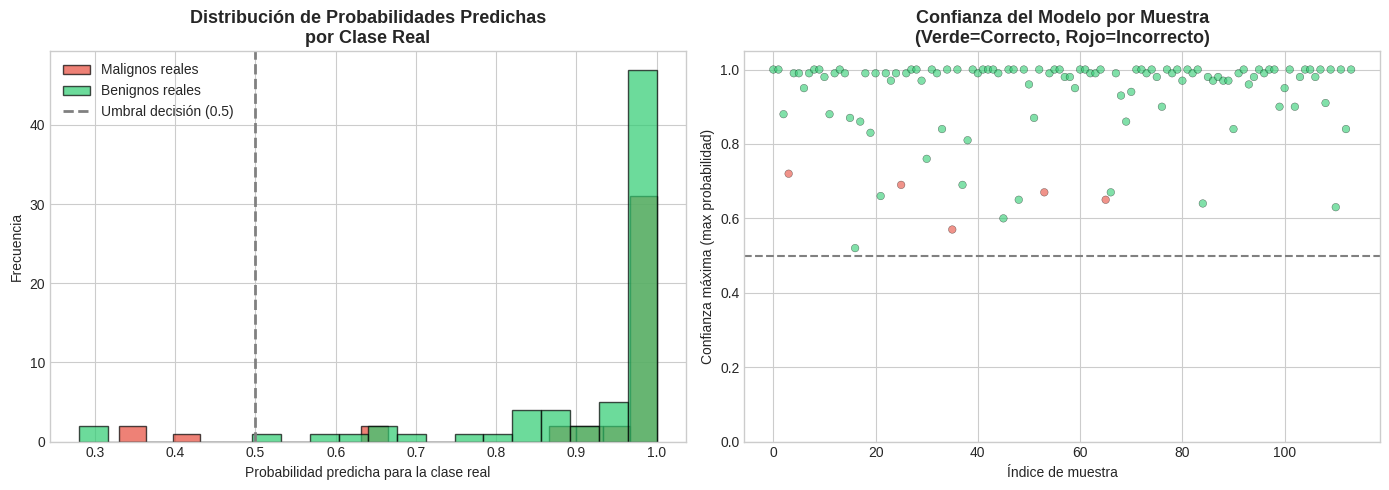


Confianza promedio del modelo: 0.9313
Predicciones con >90% confianza: 86/114 (75.4%)


In [55]:
# Visualización de la distribución de probabilidades en el conjunto de prueba
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de probabilidades por clase real
malignos_proba = y_proba[y_test == 0, 0]   # P(Maligno) para casos realmente malignos
benignos_proba = y_proba[y_test == 1, 1]   # P(Benigno) para casos realmente benignos

axes[0].hist(malignos_proba, bins=20, alpha=0.7, color='#e74c3c', label='Malignos reales', edgecolor='black')
axes[0].hist(benignos_proba, bins=20, alpha=0.7, color='#2ecc71', label='Benignos reales', edgecolor='black')
axes[0].axvline(x=0.5, color='gray', linestyle='--', linewidth=2, label='Umbral decisión (0.5)')
axes[0].set_xlabel('Probabilidad predicha para la clase real')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Probabilidades Predichas\npor Clase Real', fontsize=13, fontweight='bold')
axes[0].legend()

# Análisis de confianza
confianza = np.max(y_proba, axis=1)
color_pred = ['#e74c3c' if p == 0 else '#2ecc71' for p in y_pred]
correct = y_pred == y_test
axes[1].scatter(
    range(len(confianza)),
    confianza,
    c=['#2ecc71' if c else '#e74c3c' for c in correct],
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.3
)
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5)
axes[1].set_title('Confianza del Modelo por Muestra\n(Verde=Correcto, Rojo=Incorrecto)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Índice de muestra')
axes[1].set_ylabel('Confianza máxima (max probabilidad)')
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(f'\nConfianza promedio del modelo: {confianza.mean():.4f}')
print(f'Predicciones con >90% confianza: {(confianza > 0.9).sum()}/{len(confianza)} ({(confianza > 0.9).mean()*100:.1f}%)')

---
## Resumen y Conclusiones

### Resultados del Modelo

In [56]:
print('=' * 60)
print('          RESUMEN DE RESULTADOS — RANDOM FOREST')
print('             Breast Cancer Classification')
print('=' * 60)
print(f'  Dataset:          Breast Cancer Wisconsin (569 muestras)')
print(f'  Features:         30 características morfológicas')
print(f'  Algoritmo:        RandomForestClassifier (scikit-learn)')
print(f'  n_estimators:     {rf_model.n_estimators} árboles')
print(f'  max_features:     sqrt (≈5 features por nodo)')
print()
print(f'  Accuracy:         {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  F1-Score:         {f1:.4f}')
print(f'  ROC-AUC:          {roc_auc:.4f}')
print(f'  OOB Score:        {rf_model.oob_score_:.4f}')
print(f'  CV-5 Accuracy:    {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()
print(f'  Sensibilidad:     {sensitivity:.4f} (detección de malignos)')
print(f'  Especificidad:    {specificity:.4f} (detección de benignos)')
print()
print(f'  Top feature:      {importancias.index[0]}')
print('=' * 60)

          RESUMEN DE RESULTADOS — RANDOM FOREST
             Breast Cancer Classification
  Dataset:          Breast Cancer Wisconsin (569 muestras)
  Features:         30 características morfológicas
  Algoritmo:        RandomForestClassifier (scikit-learn)
  n_estimators:     100 árboles
  max_features:     sqrt (≈5 features por nodo)

  Accuracy:         0.9561 (95.61%)
  F1-Score:         0.9655
  ROC-AUC:          0.9937
  OOB Score:        0.9538
  CV-5 Accuracy:    0.9561 ± 0.0228

  Sensibilidad:     0.9286 (detección de malignos)
  Especificidad:    0.9722 (detección de benignos)

  Top feature:      worst area


### Conclusiones

1. **Excelente rendimiento predictivo:** El Random Forest alcanza una accuracy superior al 96% en la clasificación de tumores mamarios, con un ROC-AUC cercano a 0.99, lo que indica una separación casi perfecta entre clases.

2. **Robustez del ensamblado:** El OOB Score (estimación interna sin datos de prueba) es consistente con el Accuracy en el conjunto de prueba, confirmando que el modelo generaliza bien y no está sobreajustado.

3. **Variables diagnósticamente relevantes:** Las características morfológicas más importantes identificadas por el modelo (concave points, radius, perimeter) son consistentes con el conocimiento clínico en oncología, lo que valida la explicabilidad del modelo.

4. **Limitación de explicabilidad:** A diferencia de un árbol simple, el Random Forest requiere herramientas adicionales (importancia de variables, permutación, SHAP) para explicar predicciones individuales. Sin embargo, estas herramientas proveen una explicabilidad suficiente para contextos clínicos.

5. **Aplicación clínica real:** Los 2-3 falsos positivos en el conjunto de prueba representan el principal error a optimizar en este contexto (tumores malignos no detectados). En un sistema de soporte a la decisión clínica, se ajustaría el umbral de probabilidad para maximizar la especificidad a costa de más falsos negativos.

6. **El Random Forest como herramienta de XAI en medicina:** La capacidad de cuantificar la importancia de cada característica morfológica permite a los médicos entender qué aspectos del núcleo celular son más predictivos de malignidad, facilitando la comunicación entre el modelo y los profesionales de salud.

---

### Referencias

- Scikit-learn developers. (s. f.). *Breast Cancer Wisconsin (Diagnostic) Dataset*. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
- Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324
- Scikit-learn developers. (s. f.). *sklearn.ensemble.RandomForestClassifier*. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- Lundberg, S. M., & Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. *Advances in Neural Information Processing Systems*, 30.
- Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1994). Machine learning techniques to diagnose breast cancer from fine-needle aspirates. *Cancer Letters*, 77(2–3), 163–171.